In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['Brent Oil Futures Historical Data.csv'].decode('utf-8')))

Saving Brent Oil Futures Historical Data.csv to Brent Oil Futures Historical Data (2).csv


In [3]:
# Convert 'date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Rename 'date' column to 'ds'
data = data.rename(columns={'Date': 'ds'})

In [4]:
# Print the first 5 rows of the dataset
print(data.head())

# Get a summary of the dataset
print(data.dtypes)

# Get summary statistics for numerical columns
print(data.describe())

          ds  Price   Open   High    Low     Vol. Change %
0 2019-07-01  65.06  65.05  66.75  64.22  361.41K   -2.24%
1 2019-06-28  66.55  66.51  66.84  66.08   34.62K    0.00%
2 2019-06-27  66.55  66.05  66.82  65.63  103.16K    0.09%
3 2019-06-26  66.49  65.80  66.85  65.60  141.95K    2.21%
4 2019-06-25  65.05  64.89  65.98  64.17  205.80K    0.29%
ds          datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.                object
Change %            object
dtype: object
             Price         Open         High          Low
count  5000.000000  5000.000000  5000.000000  5000.000000
mean     65.320384    65.318124    66.179498    64.419316
std      30.340801    30.326109    30.583107    30.042614
min      17.680000    17.400000    18.050000    16.650000
25%      40.245000    40.235000    40.967500    39.435000
50%      61.830000    61.795000    62.800000    60.920000
75%      87.440000    87.450000    88

In [5]:
# Converting "Vol." column to float datatype
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000
print(data.dtypes)

ds          datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [6]:
# Check for null values in each column
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

ds          0
Price       0
Open        0
High        0
Low         0
Vol.        2
Change %    0
dtype: int64


In [7]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

ds          0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-7-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())
<ipython-input-7-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


In [8]:
# Drop a column from the dataset
data = data.drop('Change %', axis=1)

# Show the updated dataset
print(data.head())

          ds  Price   Open   High    Low      Vol.
0 2019-07-01  65.06  65.05  66.75  64.22  361410.0
1 2019-06-28  66.55  66.51  66.84  66.08   34620.0
2 2019-06-27  66.55  66.05  66.82  65.63  103160.0
3 2019-06-26  66.49  65.80  66.85  65.60  141950.0
4 2019-06-25  65.05  64.89  65.98  64.17  205800.0


In [9]:
data = data.rename(columns={'Price': 'y'})
print(data.head())

          ds      y   Open   High    Low      Vol.
0 2019-07-01  65.06  65.05  66.75  64.22  361410.0
1 2019-06-28  66.55  66.51  66.84  66.08   34620.0
2 2019-06-27  66.55  66.05  66.82  65.63  103160.0
3 2019-06-26  66.49  65.80  66.85  65.60  141950.0
4 2019-06-25  65.05  64.89  65.98  64.17  205800.0


In [10]:
from prophet import Prophet

In [11]:
# Create a Prophet model
model = Prophet()

In [12]:
# Fit the model to the data
model.fit(data)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7togltje/veqlw7th.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp7togltje/yli0rlad.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18945', 'data', 'file=/tmp/tmp7togltje/veqlw7th.json', 'init=/tmp/tmp7togltje/yli0rlad.json', 'output', 'file=/tmp/tmp7togltje/prophet_modelbljr89_z/prophet_model-20230607042054.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:20:54 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:20:56 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [14]:
# Create future dates to make predictions
future_dates = model.make_future_dataframe(periods=7)  # 7 because weekly data
future_dates.tail()

,ds
5002,2019-07-04
5003,2019-07-05
5004,2019-07-06
5005,2019-07-07
5006,2019-07-08


In [35]:
# The predict method will assign each row in future a predicted value which it names 'yhat'.
# in - sample fit
forecast = model.predict(future_dates)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
5002,2019-07-04,76.925639,66.699628,87.502544
5003,2019-07-05,76.978818,66.643657,86.962166
5004,2019-07-06,73.964554,63.384754,84.546673
5005,2019-07-07,74.046593,64.291549,84.350907
5006,2019-07-08,77.127774,67.400815,87.339637


In [26]:
# Make predictions for the future dates
forecast = model.predict(future_dates)

In [27]:
# Access the forecasted values
forecasted_values = forecast[['ds', 'yhat']].tail()

# 'yhat' represents the predicted values of the target variable in the forecasting result.
# 'ds' represents the date column in the datetime format

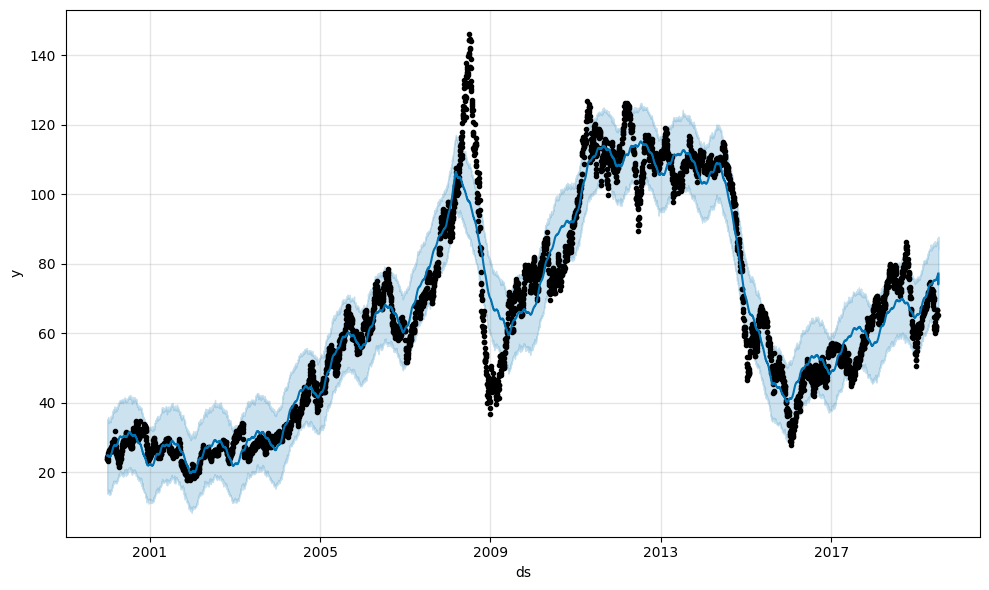

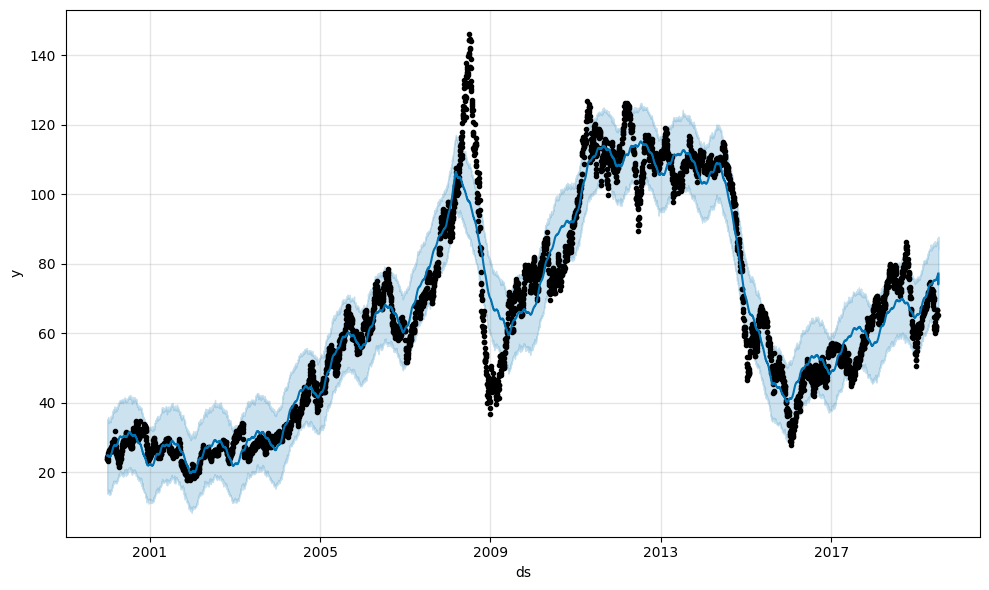

In [28]:
# Plot the forecasted values
model.plot(forecast)

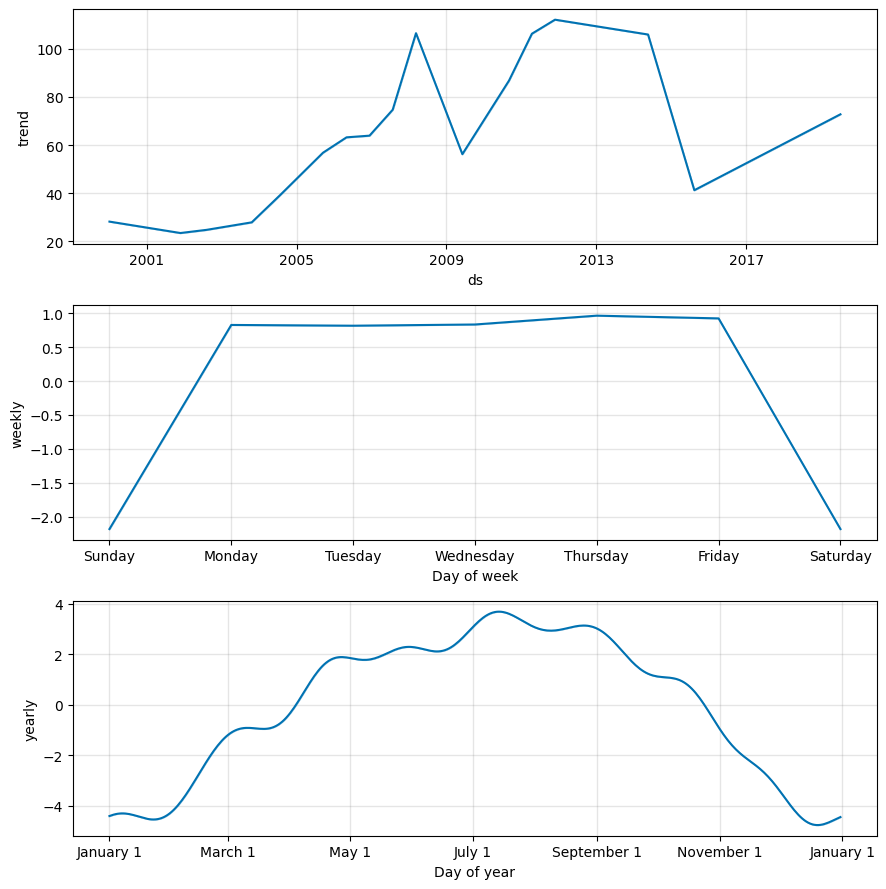

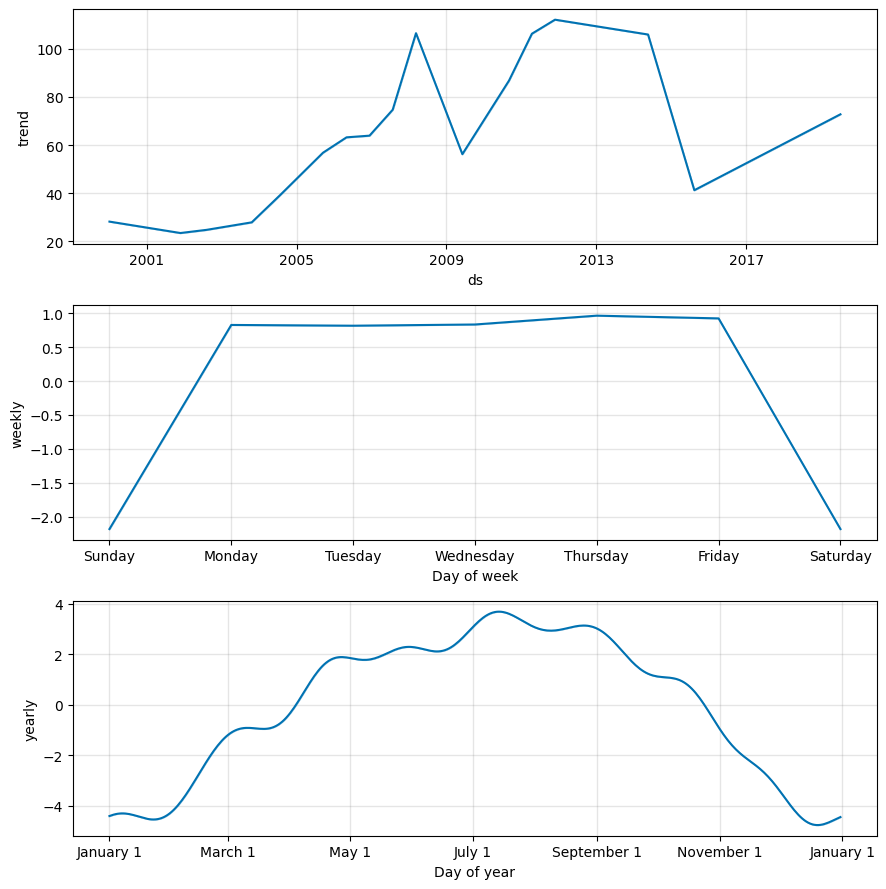

In [29]:
# Access the components of the forecast (trend, seasonality, holidays)
model.plot_components(forecast)

In [30]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [31]:
# Extract the actual values from the original dataset
actual_values = data['y'].values

In [32]:
# Extract the predicted values from the forecast dataframe
forecast = model.predict(data)
predicted_values = forecast['yhat'].values

In [33]:
# Calculate RMSE
rmse = mean_squared_error(actual_values, predicted_values, squared=False)
print('RMSE:', rmse)

RMSE: 35.728620839778706


In [34]:
from sklearn.metrics import mean_absolute_percentage_error
# Calculate MAPE using scikit-learn
mape_value = mean_absolute_percentage_error(actual_values, predicted_values)
print(mape_value)

0.6251887920227427
